# Extra Audio Only: Audio Model Training

This notebook trains and evaluates an **audio-only** genre classifier using only files under `extra_audio/`.

Pipeline:
1. Prepare extra-audio metadata and splits
2. Extract windowed CLAP embeddings
3. Train audio model (`mlp`/`logreg`/`lightgbm`)
4. Evaluate on extra-only test split

## Prerequisites

- `extra_audio/<genre>/*` is populated
- `ffmpeg` is installed
- Python env has requirements installed

In [45]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import shutil

from src.data.prepare_extra_audio import prepare_extra_audio_dataset
from src.features.extract_audio import extract_embeddings

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, log_loss

from src.models.evaluate import (
    load_embeddings,
    build_track_level_audio_eval_df,
    audio_probs_for_track_ids,
    _load_audio_preprocessor,
)



## Configuration

In [65]:
PROJECT_ROOT = Path('.').resolve()

EXTRA_AUDIO_DIR = PROJECT_ROOT / 'extra_audio'
PROCESSED_AUDIO_DIR = PROJECT_ROOT / 'data' / 'processed' / 'audio'
EXTRA_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'extra_audio_metadata.csv'
EXTRA_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits' / 'extra_audio'
EXTRA_EMBEDDINGS_NPZ = PROJECT_ROOT / 'data' / 'processed' / 'embeddings' / 'audio_embeddings_extra_windows.npz'
EXTRA_REPORT_JSON = PROJECT_ROOT / 'data' / 'processed' / 'extra_audio_prepare_report.json'
MODEL_DIR = PROJECT_ROOT / 'models' / 'extra_audio_only'
BASE_METADATA_CSV = PROJECT_ROOT / 'data' / 'processed' / 'metadata.csv'
BASE_SPLITS_DIR = PROJECT_ROOT / 'data' / 'splits'
CROSS_TEST_EMBEDDINGS_NPZ = PROJECT_ROOT / 'data' / 'processed' / 'embeddings' / 'audio_embeddings_windows.npz'
RUN_CROSS_DATASET_TEST = True

# Extra-only split config
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
SEED = 42
CONVERT_WORKERS = 8

# Embedding config
EMBED_BATCH_SIZE = 16
WINDOW_SEC = 8.0
WINDOWS_PER_TRACK = 8
WINDOW_SEED = 42

# Audio model config
AUDIO_CLASSIFIER = 'mlp'  # mlp|logreg|lightgbm
AUDIO_L2_NORM = True
AUDIO_STANDARDIZE = 'auto'  # auto|on|off
AUDIO_PCA_COMPONENTS = 0.95  # 0 disables; (0,1)=variance ratio; >=1=fixed dim

# MLP hyperparameters (used when AUDIO_CLASSIFIER='mlp')
MLP_HIDDEN_LAYERS = '1024,512,256'
MLP_LR = 5e-4
MLP_ALPHA = 3e-4
MLP_BATCH_SIZE = 256
MLP_MAX_ITER = 500
MLP_PATIENCE = 25

# Optional audio-only fusion between two audio classifiers
RUN_AUDIO_FUSION = True
AUDIO_FUSION_CLASSIFIER_A = 'logreg'
AUDIO_FUSION_CLASSIFIER_B = 'mlp'
AUDIO_FUSION_WEIGHT_SEARCH_STEPS = 41

# Probability-oriented analysis settings
PROB_ANALYSIS_DATASET = 'extra'  # extra|base
PROB_ANALYSIS_MODE = 'audio_fusion' if RUN_AUDIO_FUSION else 'audio'  # audio|audio_fusion
PROB_N_BINS = 10
PROB_N_EXAMPLES = 15

# Cluster visualization settings (Step 8)
CLUSTER_LABELS_PURE = 6
CLUSTER_LABELS_AMBIG = 6
CLUSTER_POINT_ALPHA = 0.45
CLUSTER_RANDOM_STATE = 42
CLUSTER_LABEL_MIN_SEP = 0.055
CLUSTER_LABEL_FONT_SIZE = 8
CLUSTER_LABEL_MAX_LEN = 48
CLUSTER_DIVERSITY_BY_GENRE = True
CLUSTER_PURE_PER_GENRE = 1
CLUSTER_AMBIG_PER_GENRE = 1

for p in [EXTRA_METADATA_CSV.parent, EXTRA_SPLITS_DIR, EXTRA_EMBEDDINGS_NPZ.parent, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

if not EXTRA_AUDIO_DIR.exists():
    raise FileNotFoundError(f'Expected folder not found: {EXTRA_AUDIO_DIR}')

{
    'extra_audio_dir': str(EXTRA_AUDIO_DIR),
    'splits_dir': str(EXTRA_SPLITS_DIR),
    'embeddings_npz': str(EXTRA_EMBEDDINGS_NPZ),
    'model_dir': str(MODEL_DIR),
    'audio_classifier': AUDIO_CLASSIFIER,
    'window_sec': WINDOW_SEC,
    'windows_per_track': WINDOWS_PER_TRACK,
    'audio_pca_components': AUDIO_PCA_COMPONENTS,
    'run_cross_dataset_test': RUN_CROSS_DATASET_TEST,
    'cross_test_embeddings': str(CROSS_TEST_EMBEDDINGS_NPZ),
    'run_audio_fusion': RUN_AUDIO_FUSION,
    'audio_fusion_classifiers': (AUDIO_FUSION_CLASSIFIER_A, AUDIO_FUSION_CLASSIFIER_B),
    'prob_analysis': {
        'dataset': PROB_ANALYSIS_DATASET,
        'mode': PROB_ANALYSIS_MODE,
        'bins': PROB_N_BINS,
        'examples': PROB_N_EXAMPLES,
    },
    'cluster_viz': {
        'pure_labels': CLUSTER_LABELS_PURE,
        'ambiguous_labels': CLUSTER_LABELS_AMBIG,
        'label_min_sep': CLUSTER_LABEL_MIN_SEP,
        'label_font_size': CLUSTER_LABEL_FONT_SIZE,
        'label_max_len': CLUSTER_LABEL_MAX_LEN,
        'diversity_by_genre': CLUSTER_DIVERSITY_BY_GENRE,
        'pure_per_genre': CLUSTER_PURE_PER_GENRE,
        'ambiguous_per_genre': CLUSTER_AMBIG_PER_GENRE,
    },
}

{'extra_audio_dir': '/Volumes/MZ Music\uf028/genre-classifier/extra_audio',
 'splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/extra_audio',
 'embeddings_npz': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/embeddings/audio_embeddings_extra_windows.npz',
 'model_dir': '/Volumes/MZ Music\uf028/genre-classifier/models/extra_audio_only',
 'audio_classifier': 'mlp',
 'window_sec': 8.0,
 'windows_per_track': 8,
 'audio_pca_components': 0.95,
 'run_cross_dataset_test': True,
 'cross_test_embeddings': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz',
 'run_audio_fusion': True,
 'audio_fusion_classifiers': ('logreg', 'mlp'),
 'prob_analysis': {'dataset': 'extra',
  'mode': 'audio_fusion',
  'bins': 10,
  'examples': 15},
 'cluster_viz': {'pure_labels': 6,
  'ambiguous_labels': 6,
  'label_min_sep': 0.055,
  'label_font_size': 8,
  'label_max_len': 48}}

## Step 1: Prepare Extra-Audio Metadata and Splits

This scans `extra_audio/<genre>/*`, converts/copies audio into `data/processed/audio/<track_id>.mp3`,
then creates extra-only artist-grouped train/val/test splits.

In [35]:
extra_summary = prepare_extra_audio_dataset(
    extra_audio_dir=str(EXTRA_AUDIO_DIR),
    processed_audio_dir=str(PROCESSED_AUDIO_DIR),
    out_metadata_csv=str(EXTRA_METADATA_CSV),
    out_extra_splits_dir=str(EXTRA_SPLITS_DIR),
    base_metadata_csv=None,
    base_splits_dir=None,
    out_audio_splits_dir=None,
    out_audio_metadata_csv=None,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    seed=SEED,
    bitrate=192,
    mono=False,
    sample_rate=22050,
    workers=CONVERT_WORKERS,
    report_json=str(EXTRA_REPORT_JSON),
)

extra_summary

train:   214 tracks (65.2%)  |  157 artists  |  8 genres
  val:    49 tracks (14.9%)  |  32 artists  |  8 genres
 test:    65 tracks (19.8%)  |  43 artists  |  8 genres
{
  "conversion_status": {
    "failed": 1,
    "ok": 328
  },
  "dropped_genres_filter": {},
  "extra_genres": {
    "classical": 17,
    "electronic": 46,
    "folk": 33,
    "indie": 42,
    "jazz": 49,
    "metal": 39,
    "pop": 52,
    "rock": 50
  },
  "extra_metadata_csv": "/Volumes/MZ Music\uf028/genre-classifier/data/processed/extra_audio_metadata.csv",
  "extra_scan_rows": 329,
  "extra_splits_dir": "/Volumes/MZ Music\uf028/genre-classifier/data/splits/extra_audio",
  "extra_usable_rows": 328,
  "report_json": "/Volumes/MZ Music\uf028/genre-classifier/data/processed/extra_audio_prepare_report.json"
}


{'extra_scan_rows': 329,
 'extra_usable_rows': 328,
 'extra_genres': {'pop': 52,
  'rock': 50,
  'jazz': 49,
  'electronic': 46,
  'indie': 42,
  'metal': 39,
  'folk': 33,
  'classical': 17},
 'conversion_status': {'ok': 328, 'failed': 1},
 'extra_metadata_csv': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/extra_audio_metadata.csv',
 'extra_splits_dir': '/Volumes/MZ Music\uf028/genre-classifier/data/splits/extra_audio',
 'dropped_genres_filter': {},
 'report_json': '/Volumes/MZ Music\uf028/genre-classifier/data/processed/extra_audio_prepare_report.json'}

## Step 2: Inspect Extra-Only Split Balance

In [36]:
train_df = pd.read_csv(EXTRA_SPLITS_DIR / 'train.csv')
val_df = pd.read_csv(EXTRA_SPLITS_DIR / 'val.csv')
test_df = pd.read_csv(EXTRA_SPLITS_DIR / 'test.csv')

{
    'train_rows': len(train_df),
    'val_rows': len(val_df),
    'test_rows': len(test_df),
    'train_genres': train_df['genre'].value_counts().to_dict(),
    'val_genres': val_df['genre'].value_counts().to_dict(),
    'test_genres': test_df['genre'].value_counts().to_dict(),
}

{'train_rows': 214,
 'val_rows': 49,
 'test_rows': 65,
 'train_genres': {'pop': 35,
  'rock': 35,
  'indie': 32,
  'jazz': 29,
  'electronic': 28,
  'folk': 22,
  'metal': 22,
  'classical': 11},
 'val_genres': {'jazz': 10,
  'metal': 10,
  'pop': 8,
  'electronic': 6,
  'indie': 5,
  'rock': 5,
  'folk': 3,
  'classical': 2},
 'test_genres': {'electronic': 12,
  'jazz': 10,
  'rock': 10,
  'pop': 9,
  'folk': 8,
  'metal': 7,
  'indie': 5,
  'classical': 4}}

## Step 3: Extract Extra-Only Windowed CLAP Embeddings

The embedding file is incremental by `sample_id`, so re-running only computes missing rows.

In [37]:
extract_embeddings(
    metadata_csv=str(EXTRA_METADATA_CSV),
    audio_dir=str(PROCESSED_AUDIO_DIR),
    out_file=str(EXTRA_EMBEDDINGS_NPZ),
    batch_size=EMBED_BATCH_SIZE,
    window_sec=WINDOW_SEC,
    windows_per_track=WINDOWS_PER_TRACK,
    window_seed=WINDOW_SEED,
)

Resuming: 2488 embeddings already saved
Loading CLAP model...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Load our best checkpoint in the paper.
The checkpoint is already downloaded
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm2.we

Extracting windowed: 100%|██████████| 17/17 [00:16<00:00,  1.01it/s]


Saved 2624 embeddings -> /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_extra_windows.npz  (new=136, missing_audio=0)


## Step 4: Train Extra-Only Audio Model and Optional Audio Fusion

In [38]:
def run_cmd(cmd: list[str]) -> str:
    print('$', ' '.join(cmd))
    completed = subprocess.run(cmd, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        if completed.stderr:
            print(completed.stderr)
        raise RuntimeError(f'Command failed with code {completed.returncode}')
    return completed.stdout or ''

def l2_flag() -> str:
    return '--audio_l2_norm' if AUDIO_L2_NORM else '--no_audio_l2_norm'

python_bin = sys.executable

In [39]:
run_cmd([
    python_bin, '-m', 'src.models.train',
    '--modality', 'audio',
    '--classifier', AUDIO_CLASSIFIER,
    '--train_csv', str(EXTRA_SPLITS_DIR / 'train.csv'),
    '--val_csv', str(EXTRA_SPLITS_DIR / 'val.csv'),
    '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
    '--audio_standardize', AUDIO_STANDARDIZE,
    '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
    l2_flag(),
    '--mlp_hidden_layers', MLP_HIDDEN_LAYERS,
    '--mlp_lr', str(MLP_LR),
    '--mlp_alpha', str(MLP_ALPHA),
    '--mlp_batch_size', str(MLP_BATCH_SIZE),
    '--mlp_max_iter', str(MLP_MAX_ITER),
    '--mlp_patience', str(MLP_PATIENCE),
    '--seed', str(SEED),
    '--out_dir', str(MODEL_DIR),
])

if RUN_AUDIO_FUSION:
    # Ensure classifier A exists; useful when primary AUDIO_CLASSIFIER is not logreg.
    if AUDIO_FUSION_CLASSIFIER_A != AUDIO_CLASSIFIER:
        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'audio',
            '--classifier', AUDIO_FUSION_CLASSIFIER_A,
            '--train_csv', str(EXTRA_SPLITS_DIR / 'train.csv'),
            '--val_csv', str(EXTRA_SPLITS_DIR / 'val.csv'),
            '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
            '--audio_standardize', AUDIO_STANDARDIZE,
            '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
            l2_flag(),
            '--seed', str(SEED),
            '--out_dir', str(MODEL_DIR),
        ])

    if AUDIO_FUSION_CLASSIFIER_B != AUDIO_CLASSIFIER:
        run_cmd([
            python_bin, '-m', 'src.models.train',
            '--modality', 'audio',
            '--classifier', AUDIO_FUSION_CLASSIFIER_B,
            '--train_csv', str(EXTRA_SPLITS_DIR / 'train.csv'),
            '--val_csv', str(EXTRA_SPLITS_DIR / 'val.csv'),
            '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
            '--audio_standardize', AUDIO_STANDARDIZE,
            '--audio_pca_components', str(AUDIO_PCA_COMPONENTS),
            l2_flag(),
            '--seed', str(SEED),
            '--out_dir', str(MODEL_DIR),
        ])

    run_cmd([
        python_bin, '-m', 'src.models.train',
        '--modality', 'audio_fusion',
        '--val_csv', str(EXTRA_SPLITS_DIR / 'val.csv'),
        '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
        '--audio_fusion_classifier_a', AUDIO_FUSION_CLASSIFIER_A,
        '--audio_fusion_classifier_b', AUDIO_FUSION_CLASSIFIER_B,
        '--audio_fusion_weight_search_steps', str(AUDIO_FUSION_WEIGHT_SEARCH_STEPS),
        '--out_dir', str(MODEL_DIR),
    ])


$ /opt/anaconda3/bin/python -m src.models.train --modality audio --classifier mlp --train_csv /Volumes/MZ Music/genre-classifier/data/splits/extra_audio/train.csv --val_csv /Volumes/MZ Music/genre-classifier/data/splits/extra_audio/val.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_extra_windows.npz --audio_standardize auto --audio_pca_components 0.95 --audio_l2_norm --mlp_hidden_layers 1024,512,256 --mlp_lr 0.0005 --mlp_alpha 0.0003 --mlp_batch_size 256 --mlp_max_iter 500 --mlp_patience 25 --seed 42 --out_dir /Volumes/MZ Music/genre-classifier/models/extra_audio_only
Audio model: 512-dim embeddings | 8 classes | 1712 train / 392 val embedding-rows
  audio preprocessing: l2_norm=True | standardize=True | pca=on(90d, var=0.950)
  train sources (embedding-rows): {'extra': 1712}
  val (embedding-level) macro F1: 0.6840
  val (track-level) macro F1: 0.7528
Saved -> /Volumes/MZ Music/genre-classifier/models/extra_audio_only/audio_mlp.jobl

## Step 5: Evaluate on Extra-Only Test Split

In [40]:
run_cmd([
    python_bin, '-m', 'src.models.evaluate',
    '--modality', 'audio',
    '--classifier', AUDIO_CLASSIFIER,
    '--test_csv', str(EXTRA_SPLITS_DIR / 'test.csv'),
    '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
    '--model_dir', str(MODEL_DIR),
])

conf_src = MODEL_DIR / f'confusion_audio_{AUDIO_CLASSIFIER}.png'
if conf_src.exists():
    conf_extra = MODEL_DIR / f'confusion_audio_{AUDIO_CLASSIFIER}_extra_test.png'
    shutil.copy2(conf_src, conf_extra)
    print('Saved extra-test confusion matrix copy:', conf_extra)


if RUN_AUDIO_FUSION:
    run_cmd([
        python_bin, '-m', 'src.models.evaluate',
        '--modality', 'audio_fusion',
        '--test_csv', str(EXTRA_SPLITS_DIR / 'test.csv'),
        '--embeddings', str(EXTRA_EMBEDDINGS_NPZ),
        '--audio_fusion_classifier_a', AUDIO_FUSION_CLASSIFIER_A,
        '--audio_fusion_classifier_b', AUDIO_FUSION_CLASSIFIER_B,
        '--model_dir', str(MODEL_DIR),
    ])


$ /opt/anaconda3/bin/python -m src.models.evaluate --modality audio --classifier mlp --test_csv /Volumes/MZ Music/genre-classifier/data/splits/extra_audio/test.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_extra_windows.npz --model_dir /Volumes/MZ Music/genre-classifier/models/extra_audio_only

audio_mlp  |  test macro F1: 0.8118  (65 tracks)
              precision    recall  f1-score   support

   classical      1.000     1.000     1.000         4
  electronic      1.000     1.000     1.000        12
        folk      0.857     0.750     0.800         8
       indie      0.500     0.400     0.444         5
        jazz      1.000     1.000     1.000        10
       metal      0.800     0.571     0.667         7
         pop      1.000     1.000     1.000         9
        rock      0.500     0.700     0.583        10

    accuracy                          0.831        65
   macro avg      0.832     0.803     0.812        65
weighte

## Step 6: Optional Cross-Dataset Test (Base Dataset)

This evaluates the extra-trained audio model on the original/base dataset test split.

Notes:
- The model may not include all base genres (for example if a genre is absent in `extra_audio`).
- `src.models.evaluate` will automatically skip rows with unseen genres or missing embeddings.


In [41]:
if RUN_CROSS_DATASET_TEST:
    base_test_csv = BASE_SPLITS_DIR / 'test.csv'
    if not base_test_csv.exists():
        raise FileNotFoundError(f'Missing base test split: {base_test_csv}')
    if not CROSS_TEST_EMBEDDINGS_NPZ.exists():
        raise FileNotFoundError(
            f'Missing cross-test embeddings file: {CROSS_TEST_EMBEDDINGS_NPZ}\n'
            'Create it in the full pipeline (or run extract_embeddings against base metadata).'
        )

    base_test_df = pd.read_csv(base_test_csv)
    emb = np.load(CROSS_TEST_EMBEDDINGS_NPZ, allow_pickle=True)
    emb_ids = set(map(str, emb['track_ids']))
    cover = int(base_test_df['track_id'].astype(str).isin(emb_ids).sum())
    print({
        'base_test_rows': len(base_test_df),
        'rows_with_embeddings': cover,
        'embedding_coverage': round(cover / max(1, len(base_test_df)), 4),
    })

    run_cmd([
        python_bin, '-m', 'src.models.evaluate',
        '--modality', 'audio',
        '--classifier', AUDIO_CLASSIFIER,
        '--test_csv', str(base_test_csv),
        '--embeddings', str(CROSS_TEST_EMBEDDINGS_NPZ),
        '--model_dir', str(MODEL_DIR),
    ])


    if RUN_AUDIO_FUSION:
        run_cmd([
            python_bin, '-m', 'src.models.evaluate',
            '--modality', 'audio_fusion',
            '--test_csv', str(base_test_csv),
            '--embeddings', str(CROSS_TEST_EMBEDDINGS_NPZ),
            '--audio_fusion_classifier_a', AUDIO_FUSION_CLASSIFIER_A,
            '--audio_fusion_classifier_b', AUDIO_FUSION_CLASSIFIER_B,
            '--model_dir', str(MODEL_DIR),
        ])

    conf_src = MODEL_DIR / f'confusion_audio_{AUDIO_CLASSIFIER}.png'
    if conf_src.exists():
        conf_base = MODEL_DIR / f'confusion_audio_{AUDIO_CLASSIFIER}_base_test.png'
        shutil.copy2(conf_src, conf_base)
        print('Saved base-test confusion matrix copy:', conf_base)
else:
    print('RUN_CROSS_DATASET_TEST=False -> skipping base dataset test.')


{'base_test_rows': 705, 'rows_with_embeddings': 705, 'embedding_coverage': 1.0}
$ /opt/anaconda3/bin/python -m src.models.evaluate --modality audio --classifier mlp --test_csv /Volumes/MZ Music/genre-classifier/data/splits/test.csv --embeddings /Volumes/MZ Music/genre-classifier/data/processed/embeddings/audio_embeddings_windows.npz --model_dir /Volumes/MZ Music/genre-classifier/models/extra_audio_only

audio_mlp  |  test macro F1: 0.4790  (705 tracks)
              precision    recall  f1-score   support

   classical      0.993     0.807     0.890       176
  electronic      0.603     0.369     0.458       103
        folk      0.383     0.316     0.346        98
       indie      0.180     0.262     0.213        61
        jazz      0.507     0.660     0.574        53
       metal      0.894     0.467     0.613        90
         pop      0.307     0.683     0.424        63
        rock      0.288     0.344     0.313        61

    accuracy                          0.522       70

## Step 7: Probability-Based Genre Analysis

This step treats genre predictions as a distribution (not only a hard label).

Outputs include:
- macro F1 plus probabilistic metrics (negative log loss, ECE)
- reliability curve (confidence vs accuracy)
- soft confusion matrix (average predicted probability per true genre)
- confidence and uncertainty distributions
- most ambiguous tracks (small top-1 vs top-2 margin)


In [61]:
# Local imports so this cell can run independently after kernel restarts
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, log_loss

from src.models.evaluate import (
    load_embeddings,
    build_track_level_audio_eval_df,
    audio_probs_for_track_ids,
    _load_audio_preprocessor,
)

required_vars = [
    'MODEL_DIR',
    'EXTRA_SPLITS_DIR',
    'BASE_SPLITS_DIR',
    'EXTRA_EMBEDDINGS_NPZ',
    'CROSS_TEST_EMBEDDINGS_NPZ',
    'PROB_ANALYSIS_DATASET',
    'PROB_ANALYSIS_MODE',
    'PROB_N_BINS',
    'PROB_N_EXAMPLES',
    'AUDIO_CLASSIFIER',
    'AUDIO_FUSION_CLASSIFIER_A',
    'AUDIO_FUSION_CLASSIFIER_B',
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        'Missing configuration variables for probability analysis: '
        + ', '.join(missing)
        + '\nRun the Configuration cell first.'
    )

# Resolve dataset and embeddings for analysis
if PROB_ANALYSIS_DATASET == 'extra':
    prob_test_csv = EXTRA_SPLITS_DIR / 'test.csv'
    prob_embeddings_npz = EXTRA_EMBEDDINGS_NPZ
    prob_dataset_tag = 'extra'
elif PROB_ANALYSIS_DATASET == 'base':
    prob_test_csv = BASE_SPLITS_DIR / 'test.csv'
    prob_embeddings_npz = CROSS_TEST_EMBEDDINGS_NPZ
    prob_dataset_tag = 'base'
else:
    raise ValueError("PROB_ANALYSIS_DATASET must be 'extra' or 'base'")

if not prob_test_csv.exists():
    raise FileNotFoundError(f'Missing analysis test split: {prob_test_csv}')
if not prob_embeddings_npz.exists():
    raise FileNotFoundError(f'Missing analysis embeddings file: {prob_embeddings_npz}')

le = joblib.load(MODEL_DIR / 'label_encoder.joblib')
test_df = pd.read_csv(prob_test_csv)
id_to_indices, embeddings = load_embeddings(str(prob_embeddings_npz))
eval_df = build_track_level_audio_eval_df(test_df, set(le.classes_), set(id_to_indices))
if len(eval_df) == 0:
    raise RuntimeError('No rows left for probability analysis after filtering to known genres + embeddings.')

y_true = le.transform(eval_df['genre'])

# Compute per-track probability vectors
if PROB_ANALYSIS_MODE == 'audio':
    model = joblib.load(MODEL_DIR / f'audio_{AUDIO_CLASSIFIER}.joblib')
    preproc = _load_audio_preprocessor(MODEL_DIR, AUDIO_CLASSIFIER)
    prob = audio_probs_for_track_ids(
        eval_df['track_id'],
        id_to_indices,
        embeddings,
        model,
        audio_preprocessor=preproc,
    )
    prob_mode_tag = f'audio_{AUDIO_CLASSIFIER}'
    prob_weight_info = {'mode': 'single_model'}
elif PROB_ANALYSIS_MODE == 'audio_fusion':
    clf_a = AUDIO_FUSION_CLASSIFIER_A
    clf_b = AUDIO_FUSION_CLASSIFIER_B

    model_a = joblib.load(MODEL_DIR / f'audio_{clf_a}.joblib')
    model_b = joblib.load(MODEL_DIR / f'audio_{clf_b}.joblib')
    preproc_a = _load_audio_preprocessor(MODEL_DIR, clf_a)
    preproc_b = _load_audio_preprocessor(MODEL_DIR, clf_b)

    prob_a = audio_probs_for_track_ids(
        eval_df['track_id'],
        id_to_indices,
        embeddings,
        model_a,
        audio_preprocessor=preproc_a,
    )
    prob_b = audio_probs_for_track_ids(
        eval_df['track_id'],
        id_to_indices,
        embeddings,
        model_b,
        audio_preprocessor=preproc_b,
    )

    w_path = MODEL_DIR / f'audio_fusion_weights_audioA-{clf_a}_audioB-{clf_b}.joblib'
    if w_path.exists():
        payload = joblib.load(w_path)
        weight_a = float(payload.get('weight_a', 0.5))
        weight_source = f'saved:{w_path.name}'
    else:
        weight_a = 0.5
        weight_source = 'default_equal'

    prob = weight_a * prob_a + (1.0 - weight_a) * prob_b
    prob_mode_tag = f'audio_fusion_{clf_a}_{clf_b}'
    prob_weight_info = {'weight_a': weight_a, 'weight_b': 1.0 - weight_a, 'source': weight_source}
else:
    raise ValueError("PROB_ANALYSIS_MODE must be 'audio' or 'audio_fusion'")

# Derive per-track uncertainty and ranking features
sorted_idx = np.argsort(prob, axis=1)
top1_idx = sorted_idx[:, -1]
top2_idx = sorted_idx[:, -2]
top3_idx = sorted_idx[:, -3:][:, ::-1]

confidence = prob[np.arange(len(prob)), top1_idx]
second_prob = prob[np.arange(len(prob)), top2_idx]
top2_margin = confidence - second_prob
entropy_norm = -np.sum(prob * np.log(np.clip(prob, 1e-12, 1.0)), axis=1) / np.log(prob.shape[1])

analysis_df = eval_df.copy()
analysis_df['pred_genre'] = le.inverse_transform(top1_idx)
analysis_df['confidence'] = confidence
analysis_df['top2_genre'] = le.inverse_transform(top2_idx)
analysis_df['top2_prob'] = second_prob
analysis_df['top2_margin'] = top2_margin
analysis_df['entropy_norm'] = entropy_norm
analysis_df['correct'] = (top1_idx == y_true)
for r in range(min(3, prob.shape[1])):
    idx_r = top3_idx[:, r]
    analysis_df[f'top{r+1}_genre'] = le.inverse_transform(idx_r)
    analysis_df[f'top{r+1}_prob'] = prob[np.arange(len(prob)), idx_r]

def compute_ece(y_true_idx: np.ndarray, prob_mat: np.ndarray, n_bins: int = 10):
    conf = prob_mat.max(axis=1)
    pred = prob_mat.argmax(axis=1)
    acc = (pred == y_true_idx).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)

    rows = []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == 0:
            mask = (conf >= lo) & (conf <= hi)
        else:
            mask = (conf > lo) & (conf <= hi)
        n = int(mask.sum())
        if n == 0:
            continue

        avg_conf = float(conf[mask].mean())
        avg_acc = float(acc[mask].mean())
        frac = n / len(conf)
        ece += frac * abs(avg_acc - avg_conf)
        rows.append({
            'bin': i,
            'count': n,
            'avg_conf': avg_conf,
            'accuracy': avg_acc,
            'bin_left': lo,
            'bin_right': hi,
        })

    return float(ece), pd.DataFrame(rows)

ece, cal_df = compute_ece(y_true, prob, n_bins=PROB_N_BINS)
macro_f1 = float(f1_score(y_true, top1_idx, average='macro'))
nll = float(log_loss(y_true, prob, labels=np.arange(len(le.classes_))))

summary = {
    'dataset': prob_dataset_tag,
    'mode': prob_mode_tag,
    'rows_evaluated': int(len(analysis_df)),
    'macro_f1': round(macro_f1, 4),
    'negative_log_loss': round(nll, 4),
    'ece': round(float(ece), 4),
    'mean_confidence': round(float(analysis_df['confidence'].mean()), 4),
    'mean_entropy_norm': round(float(analysis_df['entropy_norm'].mean()), 4),
    'weight_info': prob_weight_info,
}
summary


{'dataset': 'extra',
 'mode': 'audio_fusion_logreg_mlp',
 'rows_evaluated': 65,
 'macro_f1': 0.8118,
 'negative_log_loss': 0.3793,
 'ece': 0.0613,
 'mean_confidence': 0.8259,
 'mean_entropy_norm': 0.1999,
 'weight_info': {'weight_a': 0.0,
  'weight_b': 1.0,
  'source': 'saved:audio_fusion_weights_audioA-logreg_audioB-mlp.joblib'}}

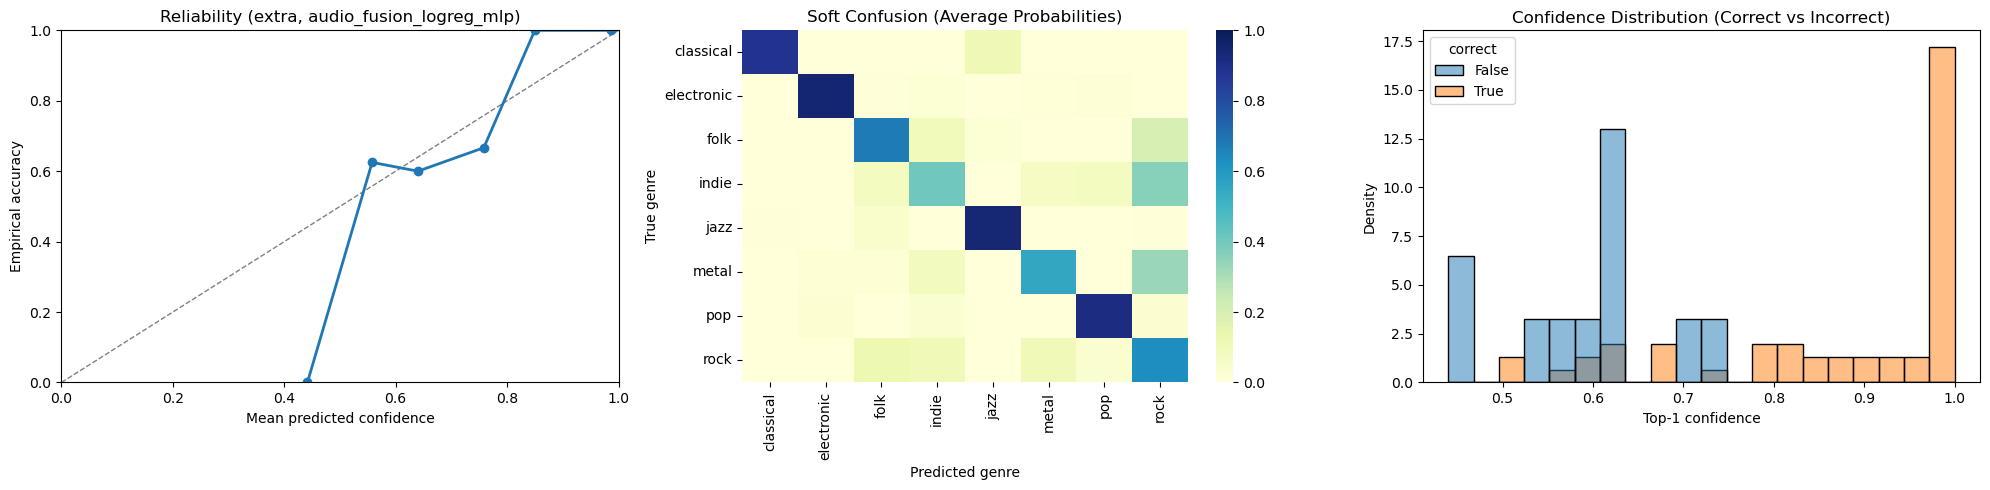

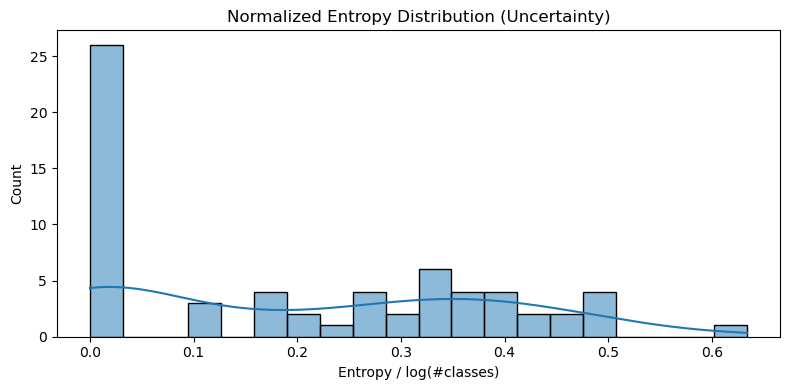

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Reliability curve
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
if len(cal_df) > 0:
    axes[0].plot(cal_df['avg_conf'], cal_df['accuracy'], marker='o', linewidth=2)
axes[0].set_title(f'Reliability ({prob_dataset_tag}, {prob_mode_tag})')
axes[0].set_xlabel('Mean predicted confidence')
axes[0].set_ylabel('Empirical accuracy')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# 2) Soft confusion matrix (true class row -> mean predicted probabilities)
n_classes = len(le.classes_)
soft = np.zeros((n_classes, n_classes), dtype=float)
for i in range(n_classes):
    mask = y_true == i
    if mask.any():
        soft[i] = prob[mask].mean(axis=0)
soft_df = pd.DataFrame(soft, index=le.classes_, columns=le.classes_)
sns.heatmap(soft_df, cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1], cbar=True)
axes[1].set_title('Soft Confusion (Average Probabilities)')
axes[1].set_xlabel('Predicted genre')
axes[1].set_ylabel('True genre')

# 3) Confidence distribution by correctness
sns.histplot(
    data=analysis_df,
    x='confidence',
    hue='correct',
    bins=20,
    stat='density',
    common_norm=False,
    ax=axes[2],
)
axes[2].set_title('Confidence Distribution (Correct vs Incorrect)')
axes[2].set_xlabel('Top-1 confidence')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(analysis_df['entropy_norm'], bins=20, kde=True, ax=ax)
ax.set_title('Normalized Entropy Distribution (Uncertainty)')
ax.set_xlabel('Entropy / log(#classes)')
plt.tight_layout()
plt.show()


In [63]:
cols = [
    c for c in [
        'track_id', 'artist', 'title', 'genre', 'pred_genre',
        'confidence', 'top2_genre', 'top2_prob', 'top2_margin', 'entropy_norm',
        'top1_genre', 'top1_prob', 'top3_genre', 'top3_prob',
    ]
    if c in analysis_df.columns
]

ambiguous = analysis_df.sort_values(['top2_margin', 'confidence'], ascending=[True, True]).head(PROB_N_EXAMPLES)
print(f'Most ambiguous tracks (n={len(ambiguous)}):')
ambiguous[cols]


Most ambiguous tracks (n=15):


,track_id,artist,title,genre,pred_genre,confidence,top2_genre,top2_prob,top2_margin,entropy_norm,top1_genre,top1_prob,top3_genre,top3_prob
40,extra_c4e06547e1692c84,Manowar,Battle Hymn,metal,rock,0.443125,metal,0.440608,0.002517,0.482481,rock,0.443125,folk,0.109750
45,extra_3499e3bdf8f52b05,System of A Down,B.Y.O.B,metal,metal,0.506812,rock,0.460571,0.046241,0.391364,metal,0.506812,indie,0.032534
38,extra_5a8aef8f7683c62b,Louis Armstrong,What a Wonderful World,jazz,jazz,0.520341,folk,0.456394,0.063947,0.388078,jazz,0.520341,rock,0.015513
57,extra_0b395eadbf029acd,Led Zeppelin,Stairway to Heaven (Remaster),rock,rock,0.557580,folk,0.426055,0.131524,0.366210,rock,0.557580,indie,0.015313
22,extra_7f75e502b8fee252,Neil Young,Heart of Gold (2009 Remaster),folk,rock,0.532807,folk,0.345926,0.186881,0.461516,rock,0.532807,indie,0.121129
58,extra_b4bf18fab84132c6,Mötley Crüe,Kickstart My Heart,rock,metal,0.591368,rock,0.402268,0.189100,0.341742,metal,0.591368,indie,0.006055
23,extra_067491bf09efe616,Neil Young,Old Man,folk,folk,0.598453,rock,0.395554,0.202898,0.339521,folk,0.598453,indie,0.005761
63,extra_9835693fc92b9fdb,The Who,Behind Blue Eyes,rock,folk,0.439927,indie,0.226635,0.213292,0.633891,folk,0.439927,rock,0.201888
28,extra_53b4eacdd76fab74,The Backseat Lovers,Pool House,indie,rock,0.555561,indie,0.338064,0.217497,0.482982,rock,0.555561,folk,0.078117
25,extra_bac968f55d6e61d7,FOLLOWAY,But Who Really Cares,indie,indie,0.610157,pop,0.374220,0.235937,0.358048,indie,0.610157,rock,0.011095


## Step 8: Genre Cluster Map and Inter-Genre Distance

This projects per-track audio embeddings into 2D to visualize genre clusters.

It also annotates (with per-genre diversity):
- **genre-pure tracks** (high confidence, low entropy, correct)
- **ambiguous tracks** (small top-1 vs top-2 margin)

By default this uses per-genre top tracks, so labels are not dominated by a single genre.

Interpretation notes:
- **PCA-1** and **PCA-2** are the top two directions of variance in the standardized embedding space.
- They are **orthogonal latent axes** (linear combinations of all embedding dimensions), not single interpretable features like tempo.
- Nearby points indicate similar embeddings; centroid distances show how separated genres are in high-dimensional space.


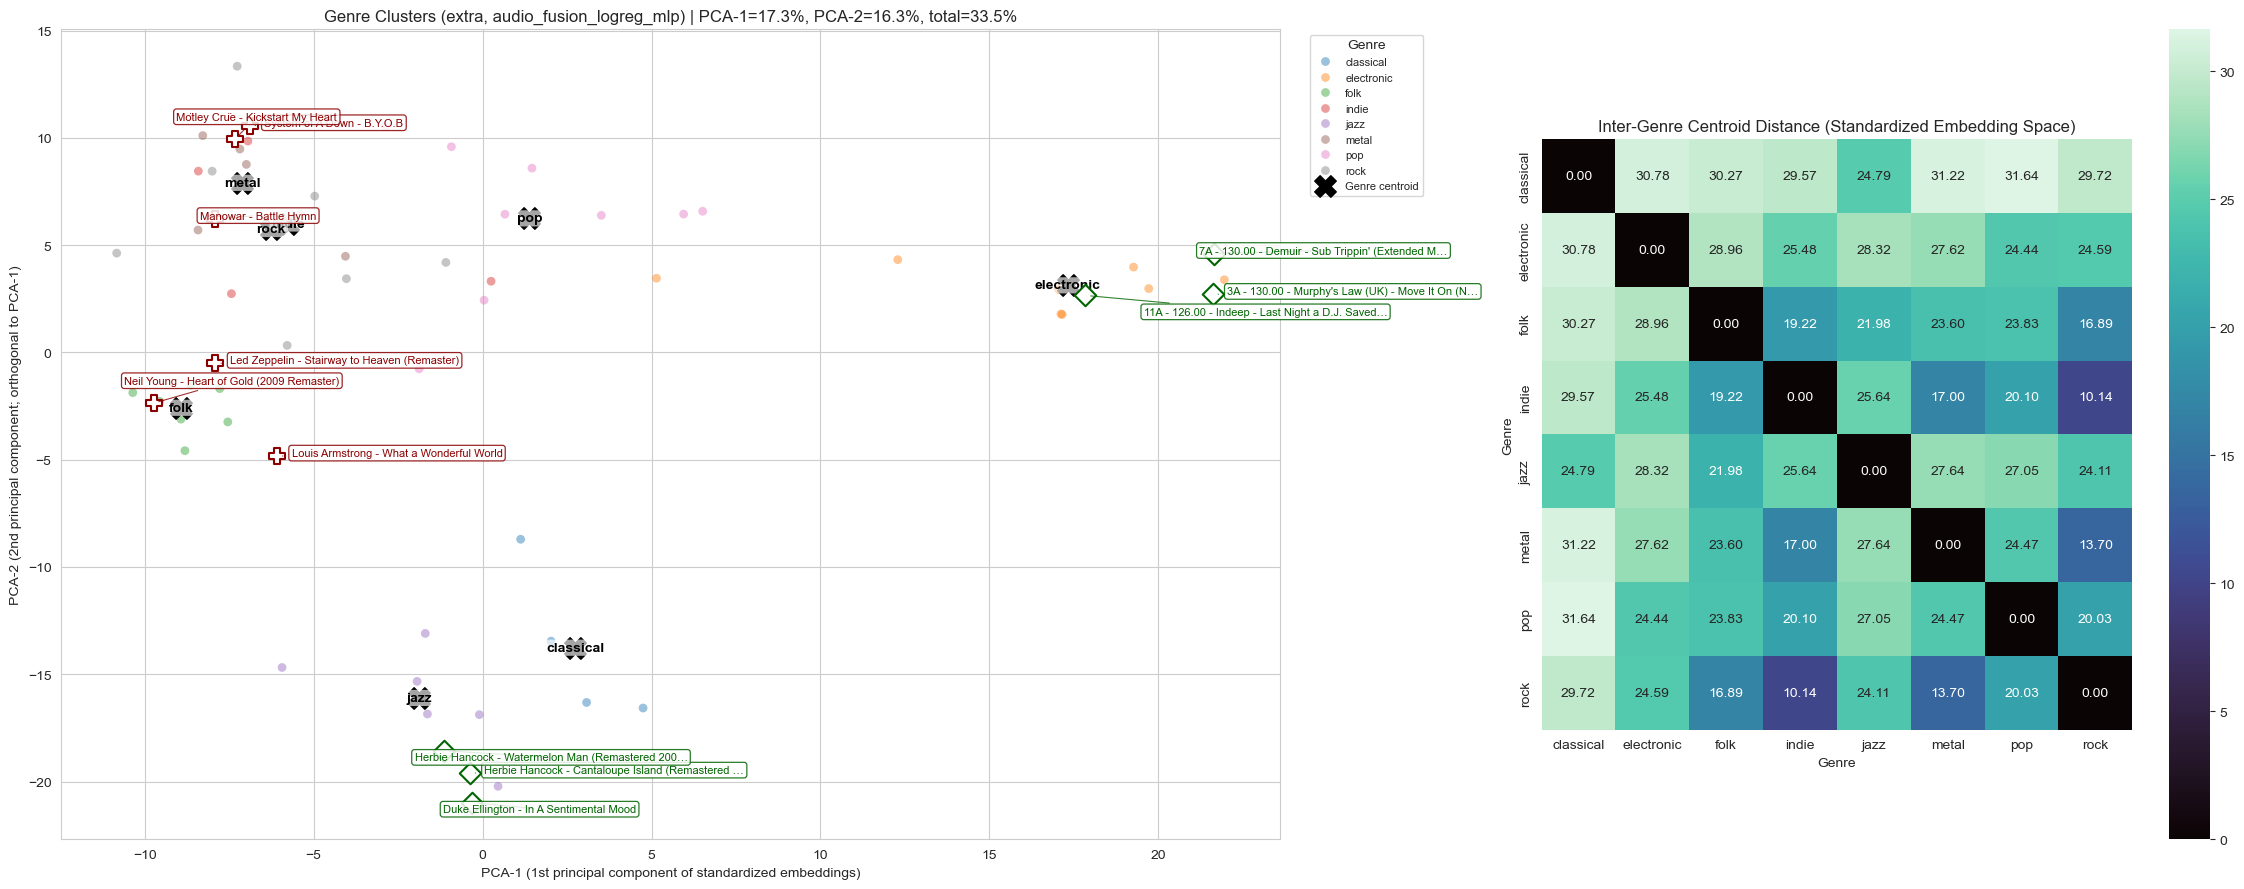

PCA interpretation: PCA-1 explains 17.3% and PCA-2 explains 16.3% of variance.
These axes are latent directions in embedding space (linear combinations of all embedding dimensions), not single hand-crafted features.
Labeled pure tracks (green):


,track_id,artist,title,genre,pred_genre,confidence,top2_margin,entropy_norm
11,extra_126a0554714a7a45,3A,130.00 - Murphy's Law (UK) - Move It On (Never...,electronic,electronic,1.000000,1.000000,3.269834e-07
13,extra_f592093fa6c956a4,7A,130.00 - Demuir - Sub Trippin' (Extended Mix),electronic,electronic,1.000000,1.000000,1.544882e-06
6,extra_fb4c2616009c6b18,11A,126.00 - Indeep - Last Night a D.J. Saved My L...,electronic,electronic,1.000000,0.999999,3.902345e-06
35,extra_2622257c3aceee50,Herbie Hancock,Cantaloupe Island (Remastered 1999_Rudy Van Ge...,jazz,jazz,1.000000,0.999999,3.832545e-06
33,extra_488a7d60699d521d,Duke Ellington,In A Sentimental Mood,jazz,jazz,0.999999,0.999998,6.422996e-06
36,extra_ca49fd61bb7734d2,Herbie Hancock,Watermelon Man (Remastered 2007),jazz,jazz,0.999998,0.999997,1.377582e-05


Labeled ambiguous tracks (red):


,track_id,artist,title,genre,pred_genre,confidence,top2_margin,entropy_norm
40,extra_c4e06547e1692c84,Manowar,Battle Hymn,metal,rock,0.443125,0.002517,0.482481
45,extra_3499e3bdf8f52b05,System of A Down,B.Y.O.B,metal,metal,0.506812,0.046241,0.391364
38,extra_5a8aef8f7683c62b,Louis Armstrong,What a Wonderful World,jazz,jazz,0.520341,0.063947,0.388078
57,extra_0b395eadbf029acd,Led Zeppelin,Stairway to Heaven (Remaster),rock,rock,0.557580,0.131524,0.366210
22,extra_7f75e502b8fee252,Neil Young,Heart of Gold (2009 Remaster),folk,rock,0.532807,0.186881,0.461516
58,extra_b4bf18fab84132c6,Mötley Crüe,Kickstart My Heart,rock,metal,0.591368,0.189100,0.341742


In [66]:
# Build per-track mean embedding matrix aligned with analysis_df/eval_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

required_vars = [
    'analysis_df', 'eval_df', 'id_to_indices', 'embeddings', 'le',
    'CLUSTER_LABELS_PURE', 'CLUSTER_LABELS_AMBIG', 'CLUSTER_POINT_ALPHA', 'CLUSTER_RANDOM_STATE',
    'CLUSTER_LABEL_MIN_SEP', 'CLUSTER_LABEL_FONT_SIZE', 'CLUSTER_LABEL_MAX_LEN',
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError('Run Step 7 first. Missing: ' + ', '.join(missing))

track_ids = eval_df['track_id'].astype(str).tolist()
track_emb = np.vstack([embeddings[id_to_indices[tid]].mean(axis=0) for tid in track_ids]).astype(np.float32)

# Standardize before PCA for a more balanced 2D projection
scaler = StandardScaler()
track_emb_z = scaler.fit_transform(track_emb)
pca2 = PCA(n_components=2, random_state=CLUSTER_RANDOM_STATE)
xy = pca2.fit_transform(track_emb_z)
var1, var2 = pca2.explained_variance_ratio_

plot_df = analysis_df.copy().reset_index(drop=True)
plot_df['x'] = xy[:, 0]
plot_df['y'] = xy[:, 1]

# Genre centroids (2D) and centroid distances in original standardized embedding space
cent2 = plot_df.groupby('genre')[['x', 'y']].mean().sort_index()
genres = cent2.index.tolist()
cent_high = np.vstack([track_emb_z[plot_df['genre'].values == g].mean(axis=0) for g in genres])
dist = pairwise_distances(cent_high, metric='euclidean')
dist_df = pd.DataFrame(dist, index=genres, columns=genres)

# Choose representative labels
pure_candidates = plot_df[plot_df['correct']].copy()
pure_candidates = pure_candidates.sort_values(
    ['confidence', 'top2_margin', 'entropy_norm'],
    ascending=[False, False, True],
)
ambig_candidates = plot_df.sort_values(
    ['top2_margin', 'entropy_norm', 'confidence'],
    ascending=[True, False, True],
)

use_diversity = bool(globals().get('CLUSTER_DIVERSITY_BY_GENRE', True))
pure_per_genre = int(globals().get('CLUSTER_PURE_PER_GENRE', 1))
ambig_per_genre = int(globals().get('CLUSTER_AMBIG_PER_GENRE', 1))
if pure_per_genre < 1 or ambig_per_genre < 1:
    raise ValueError('CLUSTER_PURE_PER_GENRE and CLUSTER_AMBIG_PER_GENRE must be >= 1')

def _select_per_genre(df, sort_cols, ascending, k):
    ranked = df.sort_values(sort_cols, ascending=ascending)
    return ranked.groupby('genre', group_keys=False).head(k).reset_index(drop=True)

if use_diversity:
    pure_sel = _select_per_genre(
        pure_candidates,
        ['confidence', 'top2_margin', 'entropy_norm'],
        [False, False, True],
        pure_per_genre,
    )
    ambig_sel = _select_per_genre(
        ambig_candidates,
        ['top2_margin', 'entropy_norm', 'confidence'],
        [True, False, True],
        ambig_per_genre,
    )
else:
    pure_sel = pure_candidates.head(CLUSTER_LABELS_PURE).copy()
    ambig_sel = ambig_candidates.head(CLUSTER_LABELS_AMBIG).copy()

def _song_label(row):
    artist = str(row.get('artist', '')).strip()
    title = str(row.get('title', '')).strip()
    if artist and artist.lower() != 'nan':
        label = f"{artist} - {title}" if title and title.lower() != 'nan' else artist
    else:
        label = title if title and title.lower() != 'nan' else str(row.get('track_id', 'track'))
    max_len = int(CLUSTER_LABEL_MAX_LEN)
    return (label[: max_len - 1] + '…') if len(label) > max_len else label

def place_labels_with_repulsion(ax, rows_df, color, marker, placed_positions, priority_col=None):
    if len(rows_df) == 0:
        return

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xr = max(xlim[1] - xlim[0], 1e-9)
    yr = max(ylim[1] - ylim[0], 1e-9)

    # Candidate offset directions (in axis-fraction units), near to far
    dirs = [
        (1, 0), (-1, 0), (0, 1), (0, -1),
        (1, 1), (-1, 1), (1, -1), (-1, -1),
        (2, 1), (-2, 1), (2, -1), (-2, -1),
        (1, 2), (-1, 2), (1, -2), (-1, -2),
    ]

    if priority_col is not None and priority_col in rows_df.columns:
        rows_df = rows_df.sort_values(priority_col, ascending=False)

    # Highlight points that will be annotated
    ax.scatter(
        rows_df['x'],
        rows_df['y'],
        s=120,
        marker=marker,
        c='white',
        edgecolors=color,
        linewidths=1.5,
        zorder=4,
    )

    min_sep = float(CLUSTER_LABEL_MIN_SEP)

    for _, r in rows_df.iterrows():
        x0, y0 = float(r['x']), float(r['y'])
        best = None
        best_score = -1e9

        for ring in range(1, 8):
            scale = 0.012 * ring
            for dxu, dyu in dirs:
                tx = x0 + dxu * scale * xr
                ty = y0 + dyu * scale * yr

                # keep labels within padded bounds
                pad_x = 0.02 * xr
                pad_y = 0.02 * yr
                tx = min(max(tx, xlim[0] + pad_x), xlim[1] - pad_x)
                ty = min(max(ty, ylim[0] + pad_y), ylim[1] - pad_y)

                # compute normalized nearest distance to already placed labels
                if placed_positions:
                    dmin = min(
                        (((tx - px) / xr) ** 2 + ((ty - py) / yr) ** 2) ** 0.5
                        for px, py in placed_positions
                    )
                else:
                    dmin = 1.0

                if dmin >= min_sep:
                    best = (tx, ty)
                    best_score = dmin
                    break
                if dmin > best_score:
                    best = (tx, ty)
                    best_score = dmin
            if best_score >= min_sep:
                break

        tx, ty = best
        label = _song_label(r)

        ax.annotate(
            label,
            xy=(x0, y0),
            xytext=(tx, ty),
            textcoords='data',
            fontsize=CLUSTER_LABEL_FONT_SIZE,
            color=color,
            bbox=dict(
                boxstyle='round,pad=0.25',
                facecolor='white',
                alpha=0.85,
                edgecolor=color,
                linewidth=0.9,
            ),
            arrowprops=dict(
                arrowstyle='-',
                color=color,
                linewidth=0.8,
                alpha=0.8,
                shrinkA=4,
                shrinkB=4,
            ),
            zorder=5,
        )
        placed_positions.append((tx, ty))

# Plot scatter + distance heatmap
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(23, 9), gridspec_kw={'width_ratios': [1.65, 1.0]})

# Scatter cloud
sns.scatterplot(
    data=plot_df, x='x', y='y', hue='genre',
    s=40, alpha=CLUSTER_POINT_ALPHA, linewidth=0, ax=axes[0],
)

# Centroids
axes[0].scatter(cent2['x'], cent2['y'], marker='X', s=240, c='black', label='Genre centroid', zorder=4)
for g, row in cent2.iterrows():
    axes[0].text(
        row['x'], row['y'], g,
        fontsize=10,
        weight='bold',
        ha='center', va='center',
        color='black',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.65, edgecolor='none'),
        zorder=4,
    )

# Fix axis bounds first so label placement uses stable coordinates
x_margin = 0.05 * max(plot_df['x'].max() - plot_df['x'].min(), 1e-9)
y_margin = 0.05 * max(plot_df['y'].max() - plot_df['y'].min(), 1e-9)
axes[0].set_xlim(plot_df['x'].min() - x_margin, plot_df['x'].max() + x_margin)
axes[0].set_ylim(plot_df['y'].min() - y_margin, plot_df['y'].max() + y_margin)

# Label placement with repulsion
placed = [(float(r['x']), float(r['y'])) for _, r in cent2.iterrows()]
place_labels_with_repulsion(
    axes[0], pure_sel, color='darkgreen', marker='D', placed_positions=placed, priority_col='confidence'
)
place_labels_with_repulsion(
    axes[0], ambig_sel, color='darkred', marker='P', placed_positions=placed, priority_col='entropy_norm'
)

axes[0].set_title(
    f"Genre Clusters ({prob_dataset_tag}, {prob_mode_tag}) | "
    f"PCA-1={var1:.1%}, PCA-2={var2:.1%}, total={var1 + var2:.1%}",
    fontsize=12,
)
axes[0].set_xlabel('PCA-1 (1st principal component of standardized embeddings)')
axes[0].set_ylabel('PCA-2 (2nd principal component; orthogonal to PCA-1)')

# Cleaner legend placement
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, frameon=True, title='Genre')

sns.heatmap(dist_df, annot=True, fmt='.2f', cmap='mako', square=True, ax=axes[1])
axes[1].set_title('Inter-Genre Centroid Distance (Standardized Embedding Space)')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.show()

print(f"PCA interpretation: PCA-1 explains {var1:.1%} and PCA-2 explains {var2:.1%} of variance.")
print(
    "These axes are latent directions in embedding space (linear combinations of all embedding dimensions), "
    "not single hand-crafted features."
)

print(
    f"Label selection strategy: per_genre={use_diversity}, "
    f"pure_per_genre={pure_per_genre}, ambiguous_per_genre={ambig_per_genre}"
)

print('Labeled pure tracks (green):')
display(
    pure_sel[
        ['track_id','artist','title','genre','pred_genre','confidence','top2_margin','entropy_norm']
    ].sort_values(['genre','confidence'], ascending=[True, False])
)
print('Labeled ambiguous tracks (red):')
display(
    ambig_sel[
        ['track_id','artist','title','genre','pred_genre','confidence','top2_margin','entropy_norm']
    ].sort_values(['genre','top2_margin'], ascending=[True, True])
)


## Artefacts

- Extra metadata: `data/processed/extra_audio_metadata.csv`
- Extra splits: `data/splits/extra_audio/{train,val,test}.csv`
- Extra embeddings: `data/processed/embeddings/audio_embeddings_extra_windows.npz`
- Model + preprocessor: `models/extra_audio_only/`
- Confusion matrix: `models/extra_audio_only/confusion_audio_<classifier>.png`

- Extra-test confusion matrix copy: `models/extra_audio_only/confusion_audio_<classifier>_extra_test.png`
- Base-test confusion matrix copy (if enabled): `models/extra_audio_only/confusion_audio_<classifier>_base_test.png`
- Audio-fusion weights (if enabled): `models/extra_audio_only/audio_fusion_weights_audioA-<clfA>_audioB-<clfB>.joblib`
- Audio-fusion confusion matrix (if enabled): `models/extra_audio_only/confusion_audio_fusion_audioA-<clfA>_audioB-<clfB>.png`
- Probability-analysis figures are shown inline in Step 7 (reliability, soft confusion, uncertainty)
- Step 8 adds inline visuals: genre-cluster map, centroid-distance heatmap, and labeled pure/ambiguous songs
